# Actividad 5.10 - MNIST

Este notebook hace únicamente:

1. Cargar MNIST y usar un subconjunto de 1000 muestras.
2. Probar componentes de PCA hasta alcanzar al menos el 80% de varianza explicada (con gráfica).
3. Ejecutar k-Means con 20 clusters sobre la dimensionalidad reducida por PCA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Carga explícita de MNIST (dataset completo) y reducción a las 1000 primeras muestras
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_full = mnist.data.astype(np.float32)

X = X_full[:1000]
print(f"MNIST cargado: {X_full.shape}")
print(f"Subconjunto usado: {X.shape}")

# Escalado de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

MNIST cargado: (70000, 784)
Subconjunto usado: (1000, 784)


Componentes para >=80%: 81
Varianza acumulada en ese punto: 0.8026


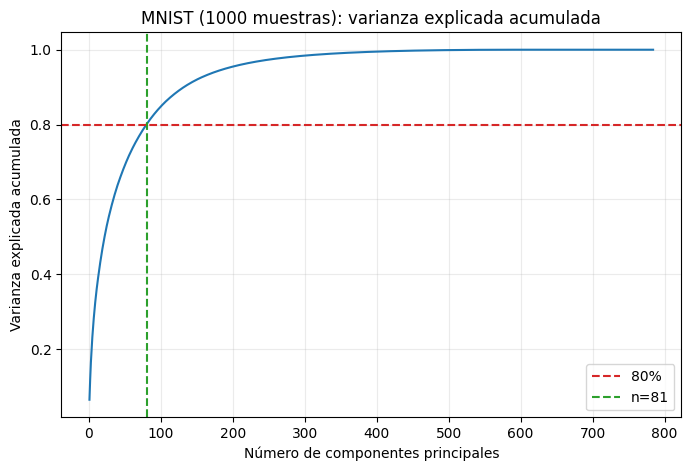

In [2]:
# 1) Probar componentes principales hasta llegar a >= 80% de varianza
pca_test = PCA(random_state=42)
pca_test.fit(X_scaled)

var_acum = np.cumsum(pca_test.explained_variance_ratio_)
n_components_80 = int(np.argmax(var_acum >= 0.80) + 1)

print(f"Componentes para >=80%: {n_components_80}")
print(f"Varianza acumulada en ese punto: {var_acum[n_components_80 - 1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(var_acum) + 1), var_acum, color="tab:blue")
plt.axhline(0.80, color="tab:red", linestyle="--", label="80%")
plt.axvline(n_components_80, color="tab:green", linestyle="--", label=f"n={n_components_80}")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("MNIST (1000 muestras): varianza explicada acumulada")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [3]:
# 2) y 3) PCA con la dimensionalidad elegida + k-Means (k=20) en subconjunto de 1000
pca = PCA(n_components=n_components_80, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=20, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_pca)

print(f"Forma tras PCA: {X_pca.shape}")
print(f"Clusters configurados: 20")
print(f"Inercia final: {kmeans.inertia_:.2f}")

# Tamaños de cluster para verificar partición
sizes = np.bincount(labels, minlength=20)
print("Tamaño de cada cluster:")
print(sizes)

Forma tras PCA: (1000, 81)
Clusters configurados: 20
Inercia final: 309140.16
Tamaño de cada cluster:
[ 46  35  38  82 111  41  76   5  40   1  59  10  28  75   1  53  28 102
  27 142]
